# Installing and Using the bagelR Package

## Installing bagelR

The **bagelR** package can be installed via an interactive **R** session using the following code.

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR@development",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)

Using GitHub PAT from the git credential store.




Running `R CMD build`...



* checking for file ‘/tmp/RtmpaGfCBA/remotes1916945de2d618/grosed-bagel-91ee4a7/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.4.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check package version

In [2]:
packageVersion("bagelR")

[1] ‘1.4.0’

## Using bagelR - 1 : Detecting Change in Mean

#### Load the bagel package

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




### Example 1 - no change

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 1 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

#### Define the prior function

In [5]:

prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Define the transform function

In [6]:
transform <- function(tau)
{
	return(matrix(c(1,1),1,2,byrow=TRUE))
}

#### Generate some data - no change

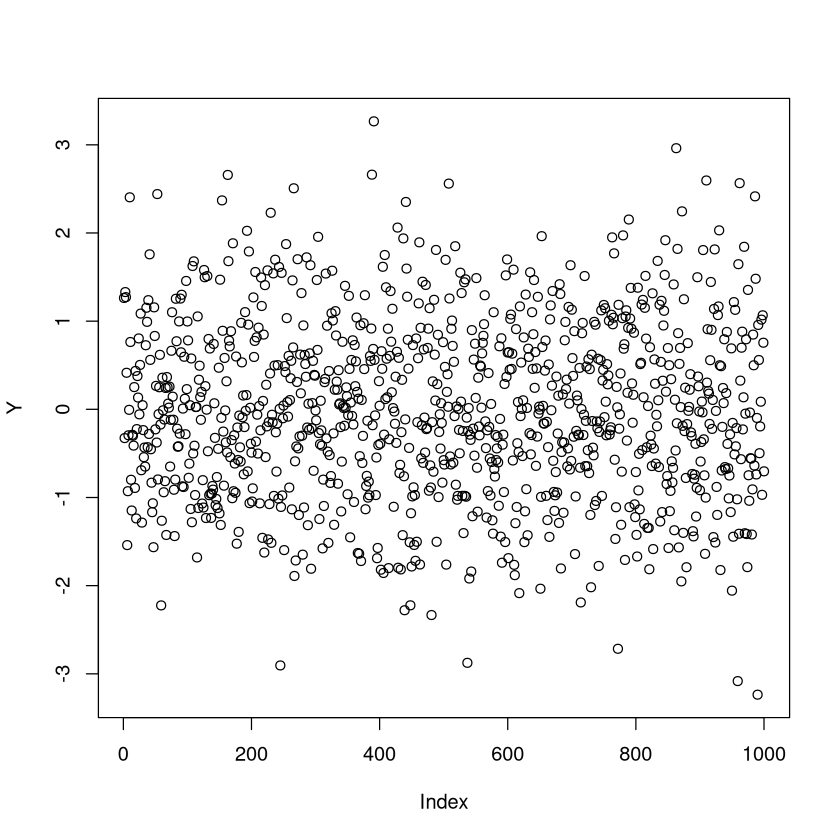

In [7]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Set model parameters 

In [8]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 200
threshold <- 0.8

#### Offline analysis - known variance

In [9]:
results <- bagel_kv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            noise_sd,
					            max_particles,
					            threshold)

#### Check for a changepoint

In [10]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

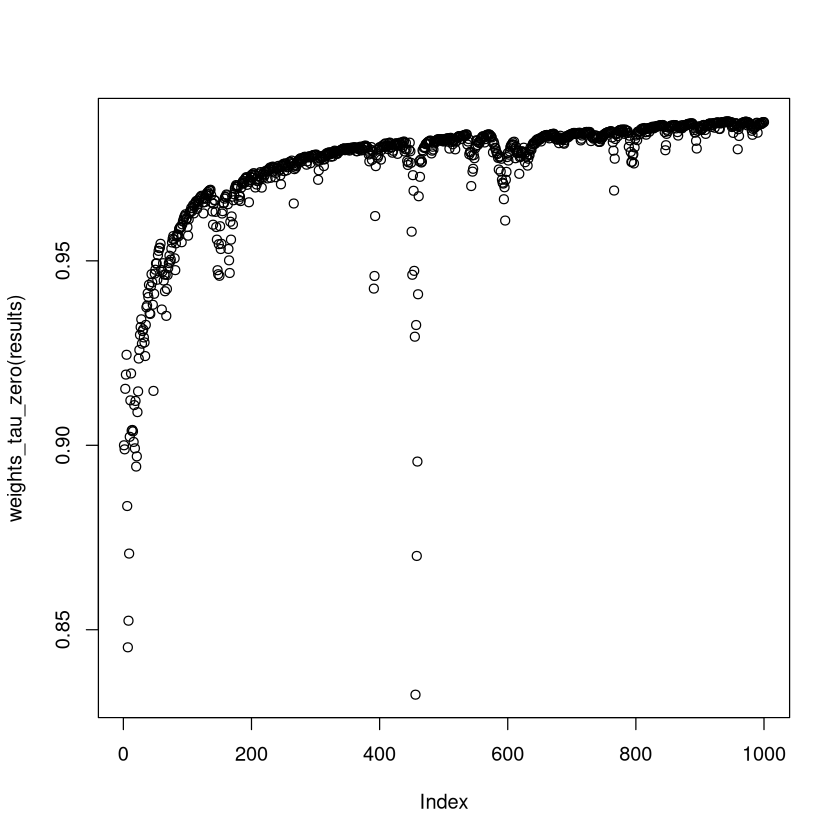

In [11]:
plot(weights_tau_zero(results))

#### Offline analysis - uknown variance

In [12]:
nu <- 1.0
iota <- 1.0

In [13]:
results <- bagel_uv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            nu,
                                iota,
					            max_particles,
					            threshold)

#### Check for a changepoint

In [14]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

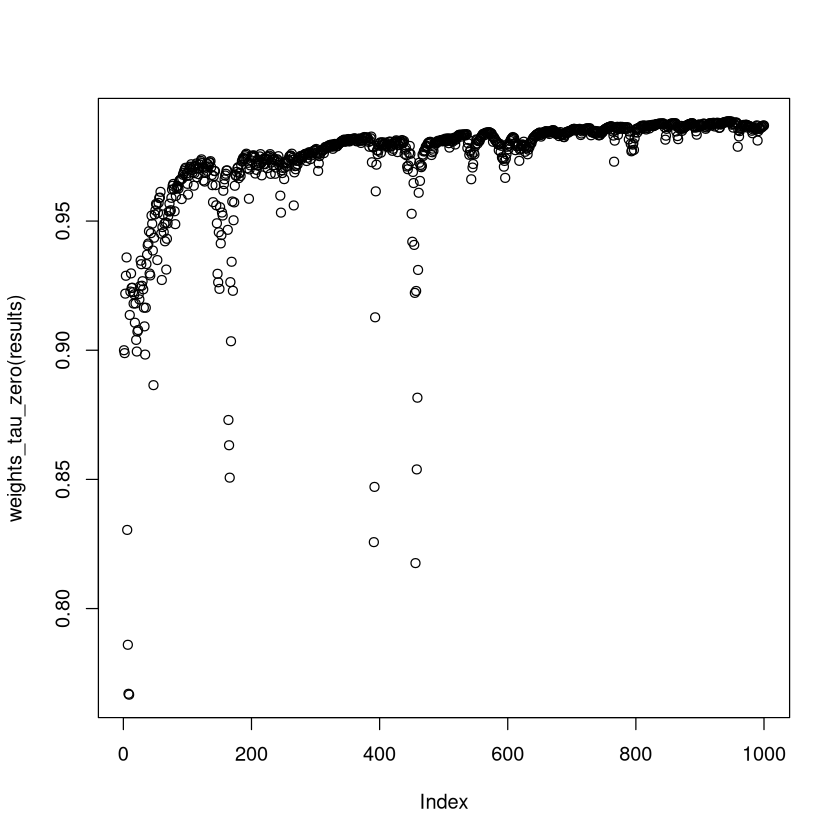

In [15]:
plot(weights_tau_zero(results))

### Example 2 - single change in mean

#### Generate some data - change at t = 501 

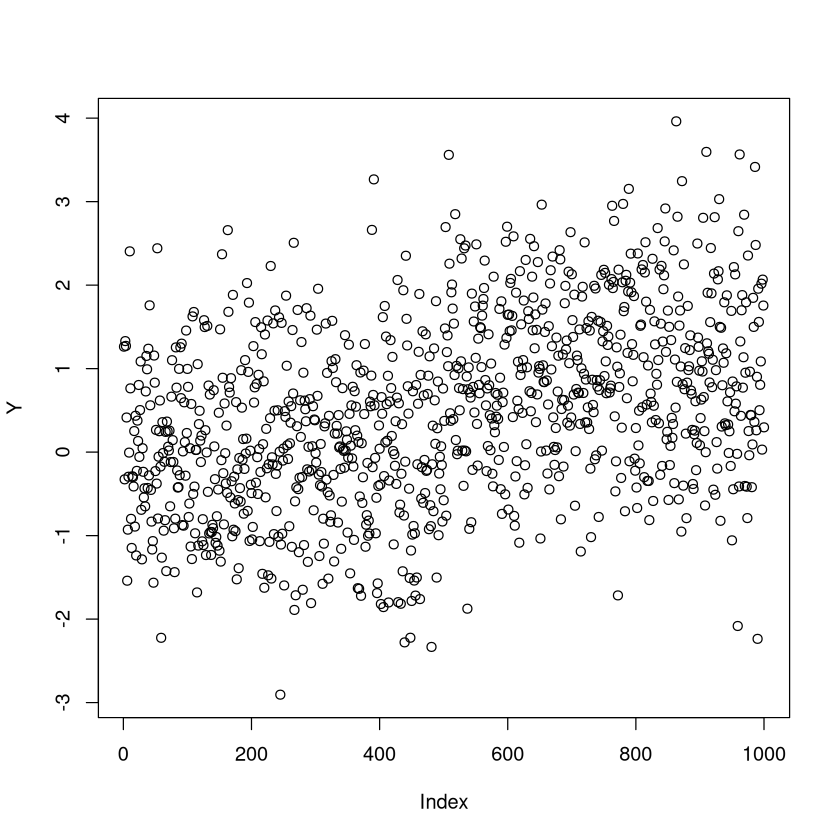

In [16]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

#### Offline analysis - known variance

In [17]:
results <- bagel_kv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            noise_sd,
					            max_particles,
					            threshold)

In [18]:
changepoint(results)

$location
[1] 501

$detected
[1] 513

#### Check for a changepoint

In [19]:
changepoint(results)

$location
[1] 501

$detected
[1] 513

#### Visualise weight at tau = 0

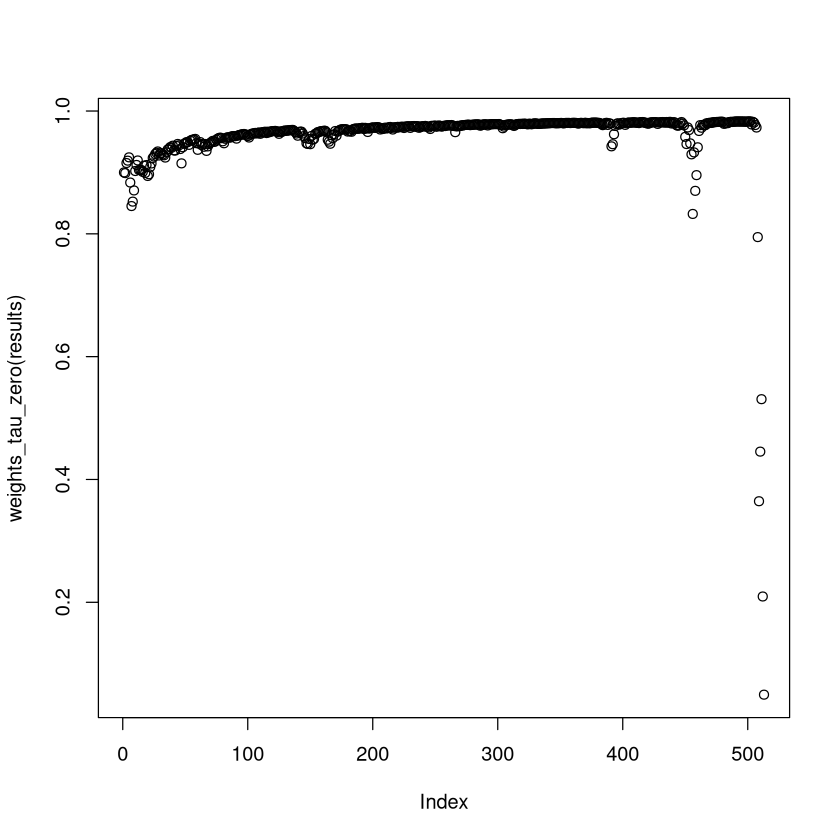

In [20]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

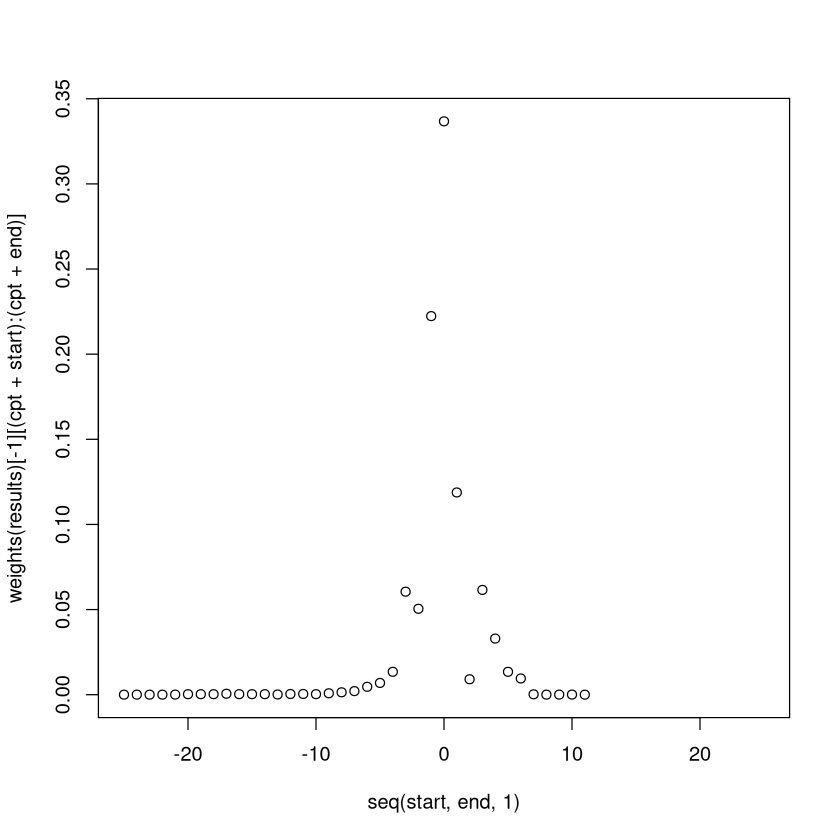

In [21]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [22]:
results <- bagel_uv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            nu,
                                iota,
					            max_particles,
					            threshold)

#### Check for a changepoint

In [23]:
changepoint(results)

$location
[1] 501

$detected
[1] 512

#### Visualise weight at tau = 0

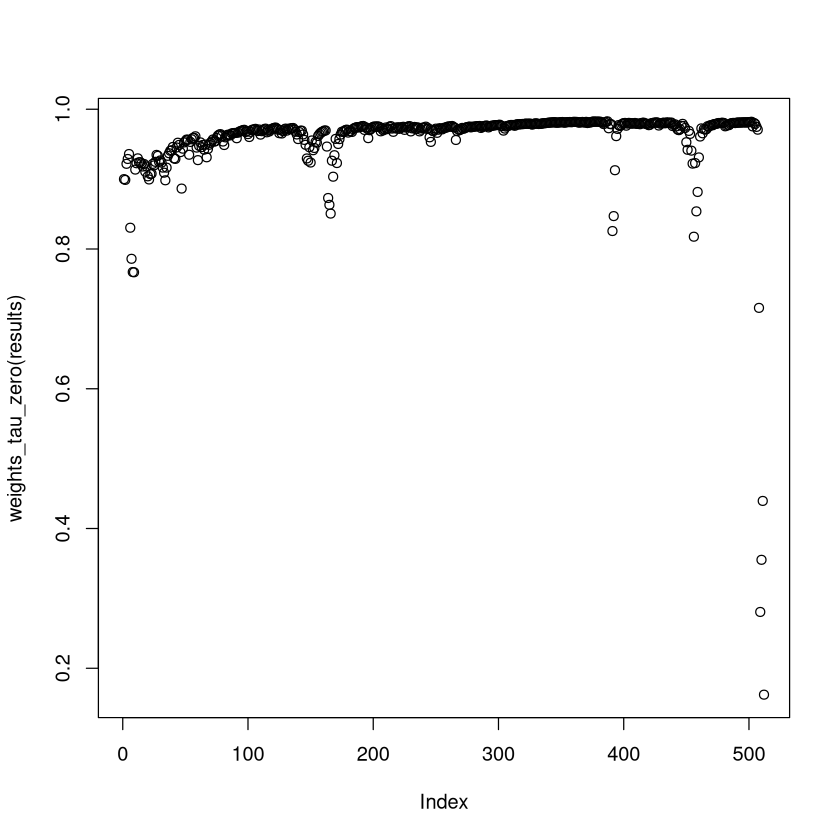

In [24]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

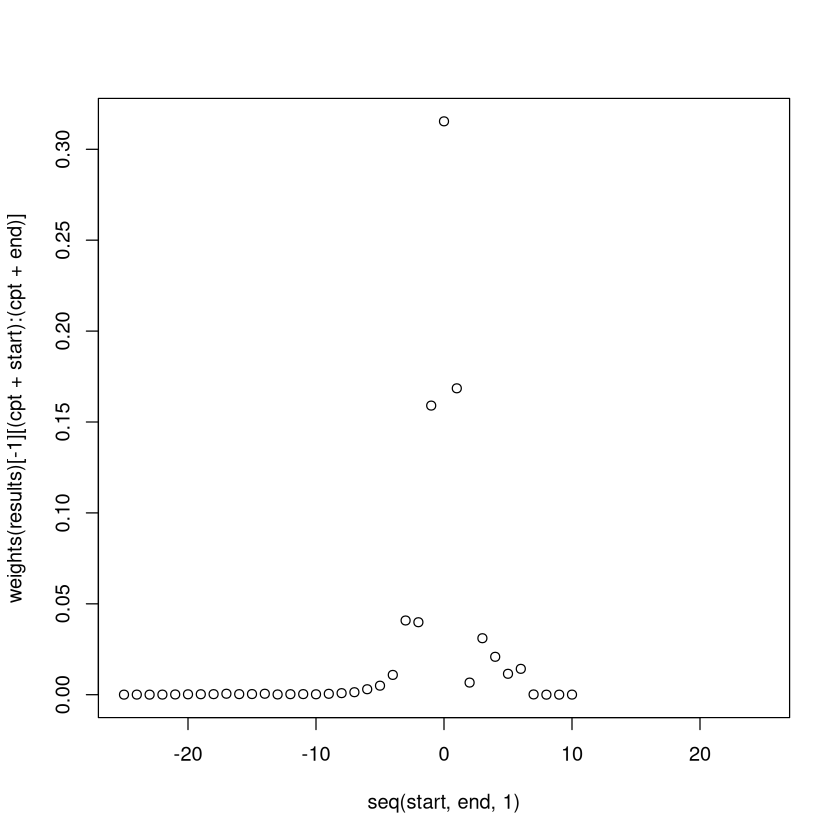

In [25]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

### Example 3 - single change in mean different prior

#### Define new prior

In [26]:
prior <- function(t)
{
  mu1<-1;
  delta1<-1
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta1*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- delta1*matrix(c(1,-1,-1,2),nr=2,nc=2)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Offline analysis - known variance

In [27]:
results <- bagel_kv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            noise_sd,
					            max_particles,
					            threshold)

#### Check for a changepoint

In [28]:
changepoint(results)

$location
[1] 501

$detected
[1] 509

#### Visualise weight at tau = 0

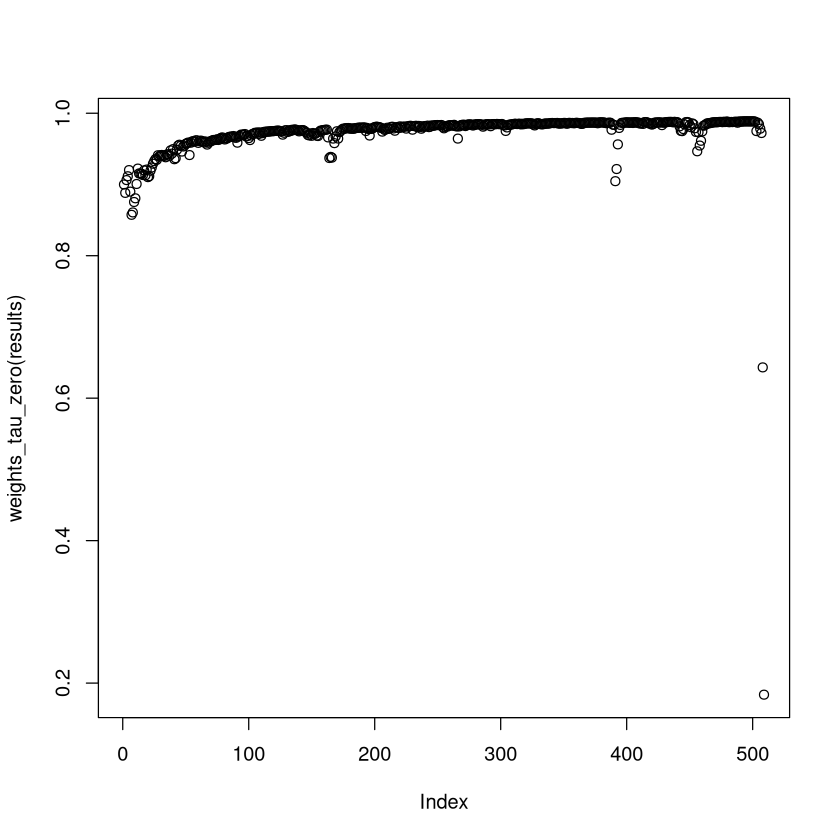

In [29]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

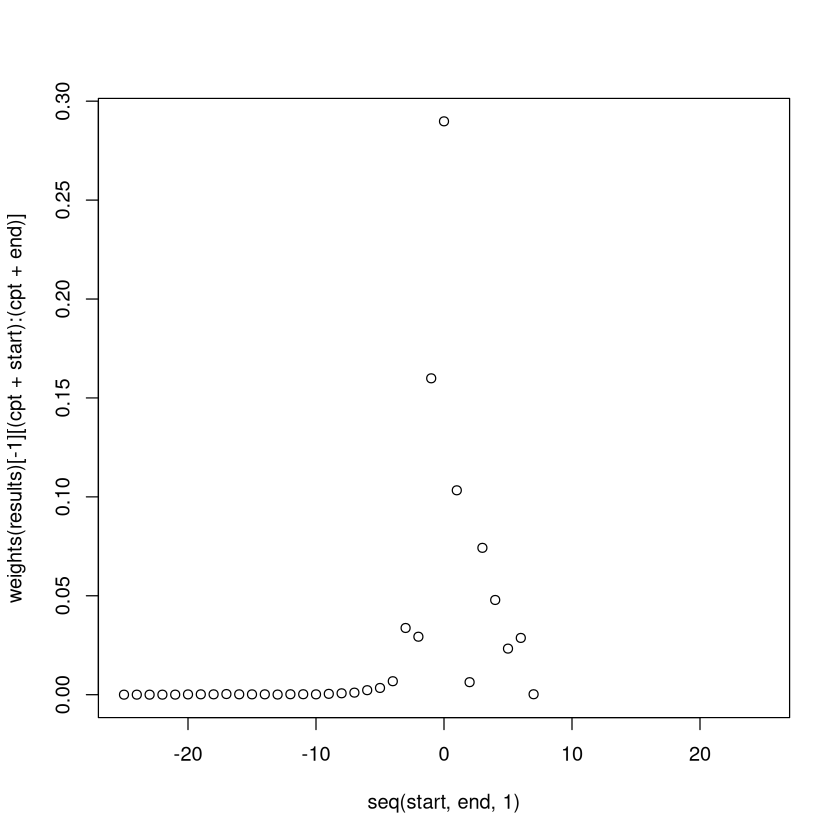

In [30]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [31]:
results <- bagel_uv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            nu,
                                iota,
					            max_particles,
					            threshold)

#### Check for a changepoint

In [32]:
changepoint(results)

$location
[1] 501

$detected
[1] 509

#### Visualise weight at tau = 0

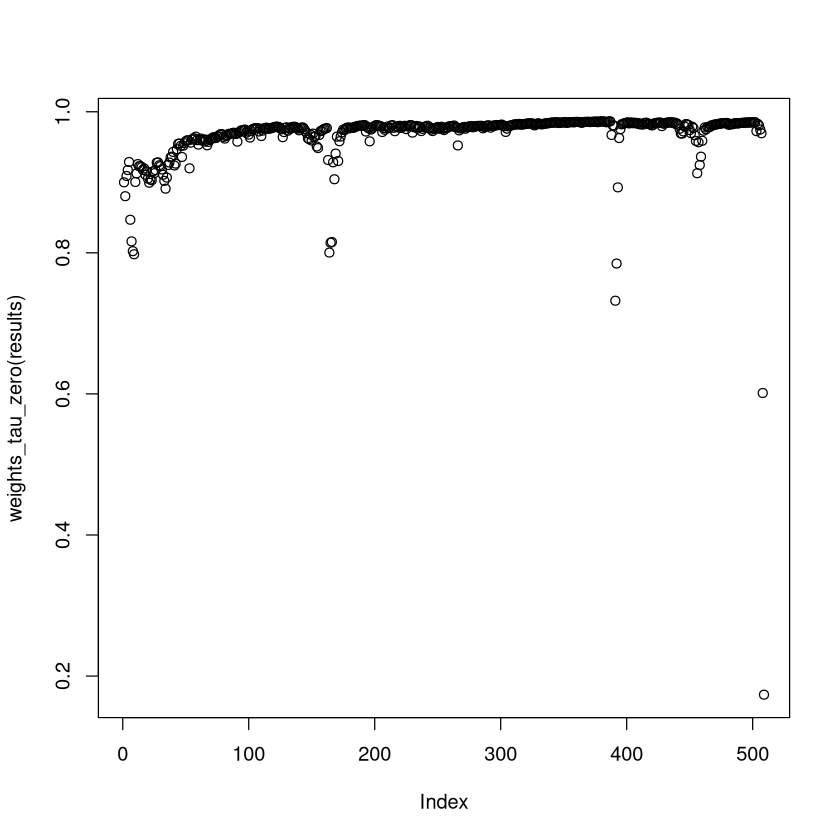

In [33]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

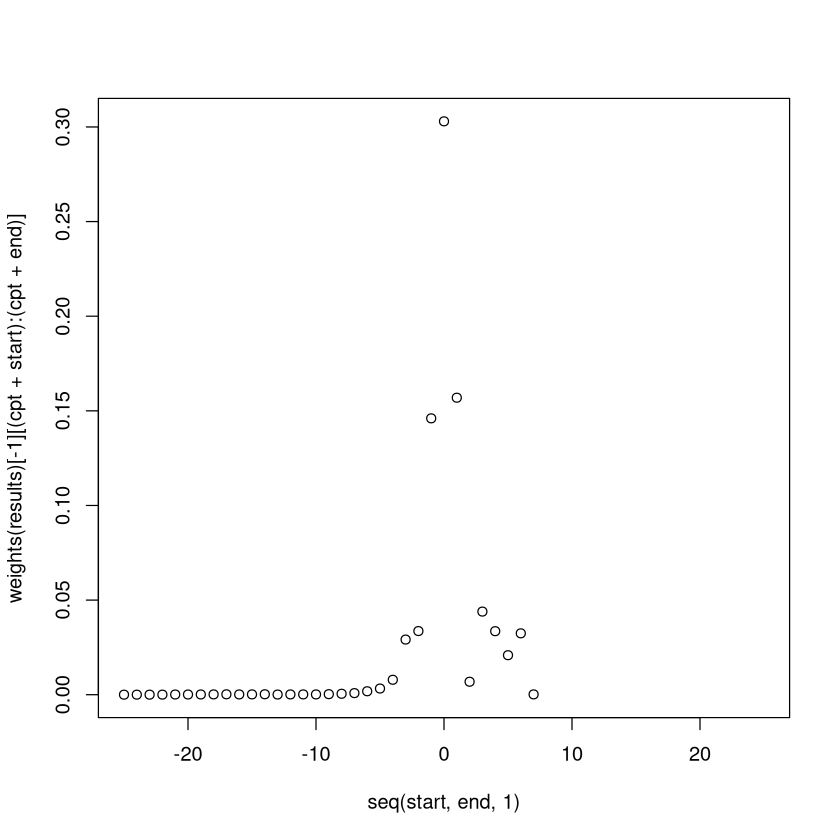

In [34]:
cpt = changepoint(results)$location
start <- -25
end <- 25
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

## Using bagelR - 2 : Detecting Change in Slope

### Example 1 - no change

#### Generate some data - no change

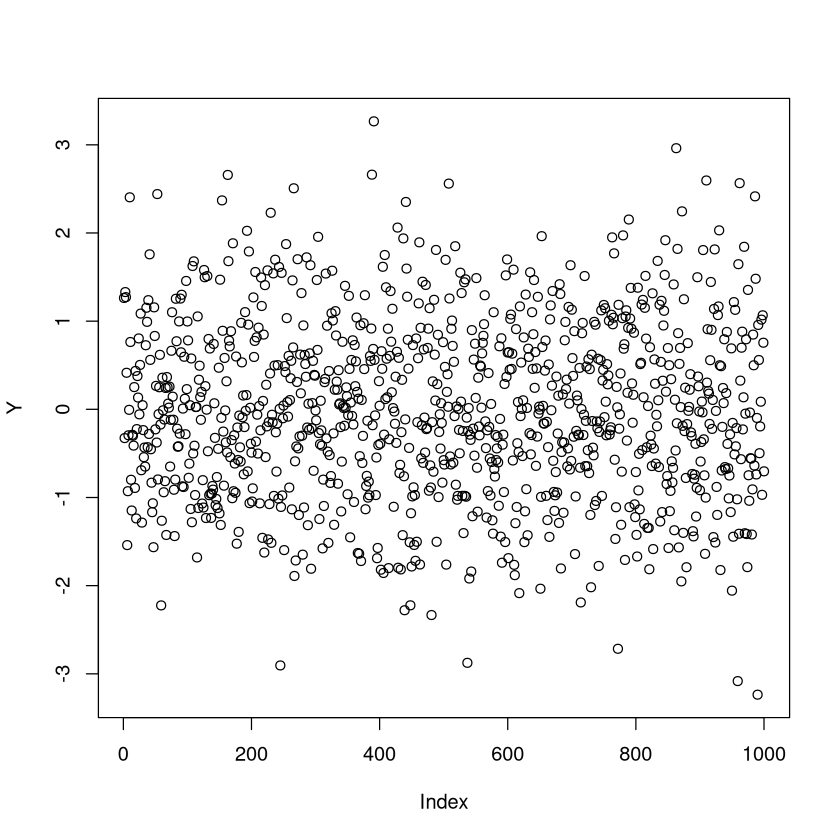

In [35]:
set.seed(0)
Y <- rnorm(1000,0,1)
plot(Y)

#### Define the feature vector function 

These functions for the **feature vector** and the **prior** correspeond to example 2 in "**Bagel : A Fast Baysian Online Changepoint Detection Algorithm for Linear Models**" *Fearnhead et al.*

In [36]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
     M <- matrix(c(0),nc=1,nr=2)	  
     M[1,1] <- 1
     M[2,1] <- t
     return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=4)	  
    M[1,1] <- 1
    M[2,1] <- t
    if(t > tau)
    {
      M[3,1] <- 1
      M[4,1] <- t
    }
  return(M)
  }
}

#### Define the prior function

In [37]:
prior <- function(t)
{
  if(t == 1)
  {
     mu <- matrix(c(0),nc=1,nr=2)
     sigma <- diag(2)
     return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(0),nc=1,nr=4)
  sigma <- diag(4)
  sigma[3,3] <- (t-1)*(t-1)
  sigma[4,3] <- sigma[3,4] <- -(t-1)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Define the transformation function

In [38]:
transform <- function(tau)
{
	return(matrix(c(1,tau+1,1,tau+1,0,1,0,1),2,4,byrow=TRUE))
}

#### Set model parameters 

In [39]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 250
threshold <- 0.8

#### Offline analysis - known variance

In [40]:
results <- bagel_kv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            noise_sd,
					            max_particles,
					            threshold)

#### Check for a changepoint

In [41]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

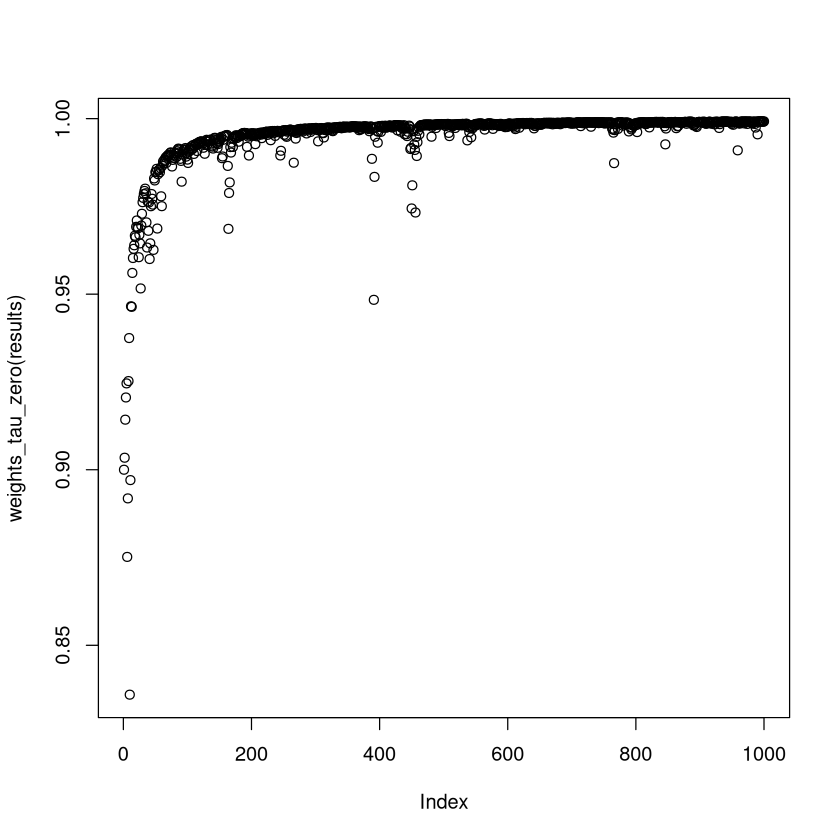

In [42]:
plot(weights_tau_zero(results))

#### Offline analysis - unknown variance

In [43]:
results <- bagel_uv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            nu,
                                iota,
					            max_particles,
					            threshold)

#### Check for a changepoint

In [44]:
changepoint(results)

[1] NA

#### Visualise weight at tau = 0

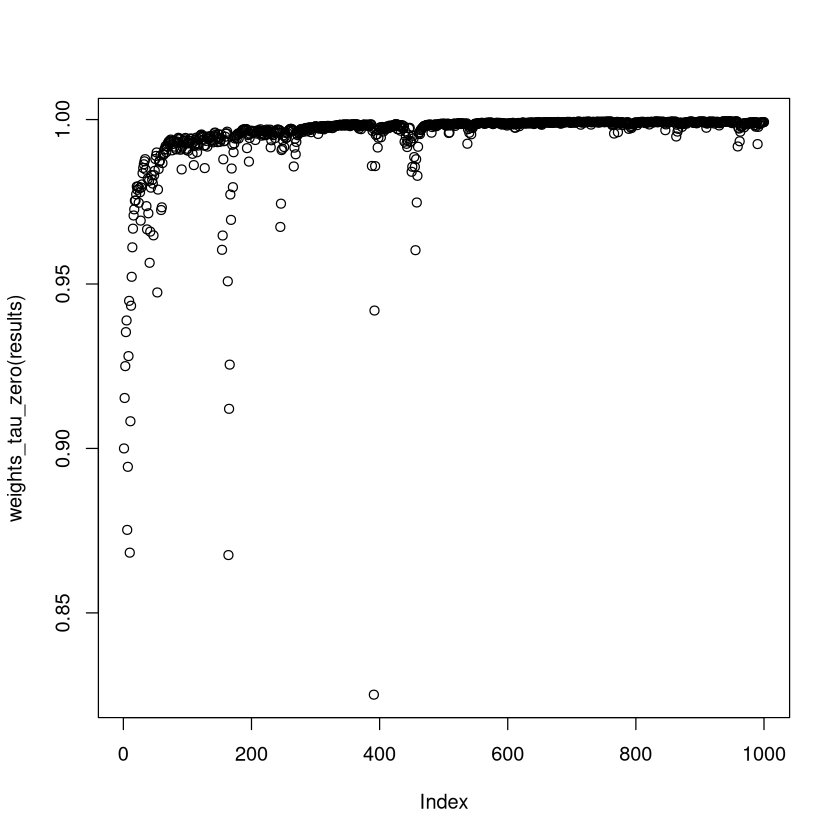

In [45]:
plot(weights_tau_zero(results))

### Example 2 - single change in slope

#### Generate data with change in slope at t = 1000

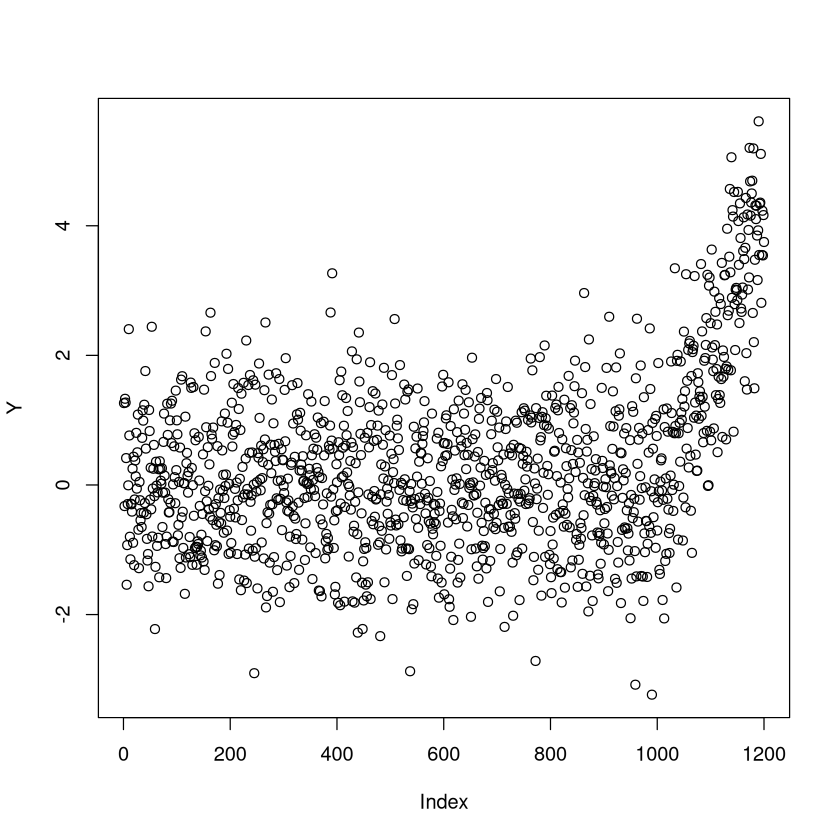

In [46]:
set.seed(0)
Y <- c(rnorm(1000,0,1),seq(1,200,1)/50 + rnorm(200,0,1))
plot(Y)

#### Offline analysis - known variance

In [47]:
results <- bagel_kv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            noise_sd,
					            max_particles,
					            threshold)

#### Check for a changepoint

In [48]:
changepoint(results)

$location
[1] 1021

$detected
[1] 1058

#### Visualise weight at tau = 0

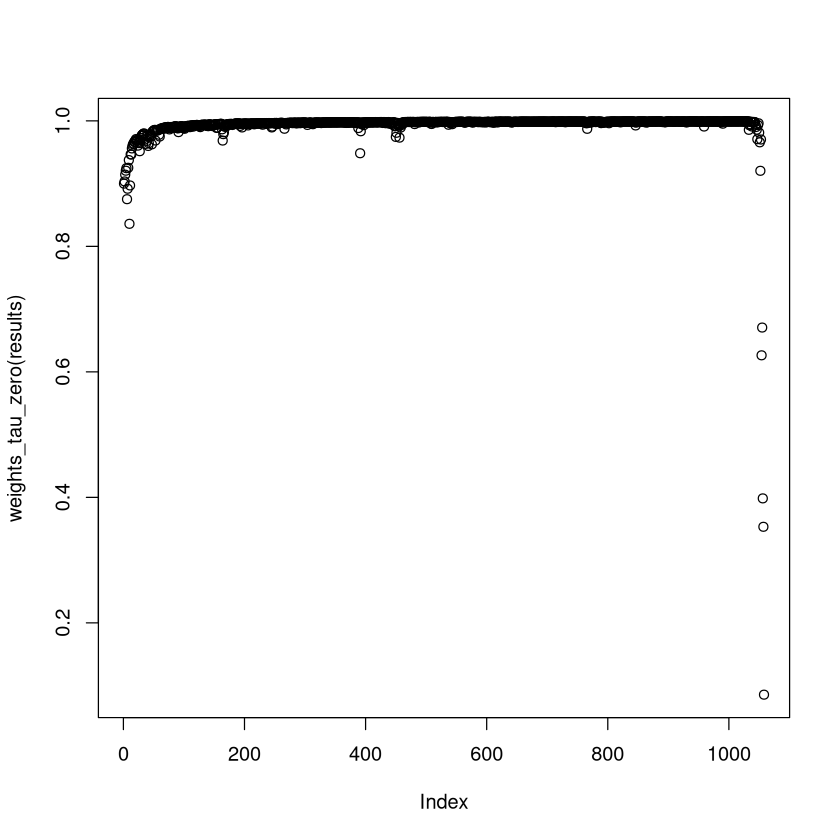

In [49]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

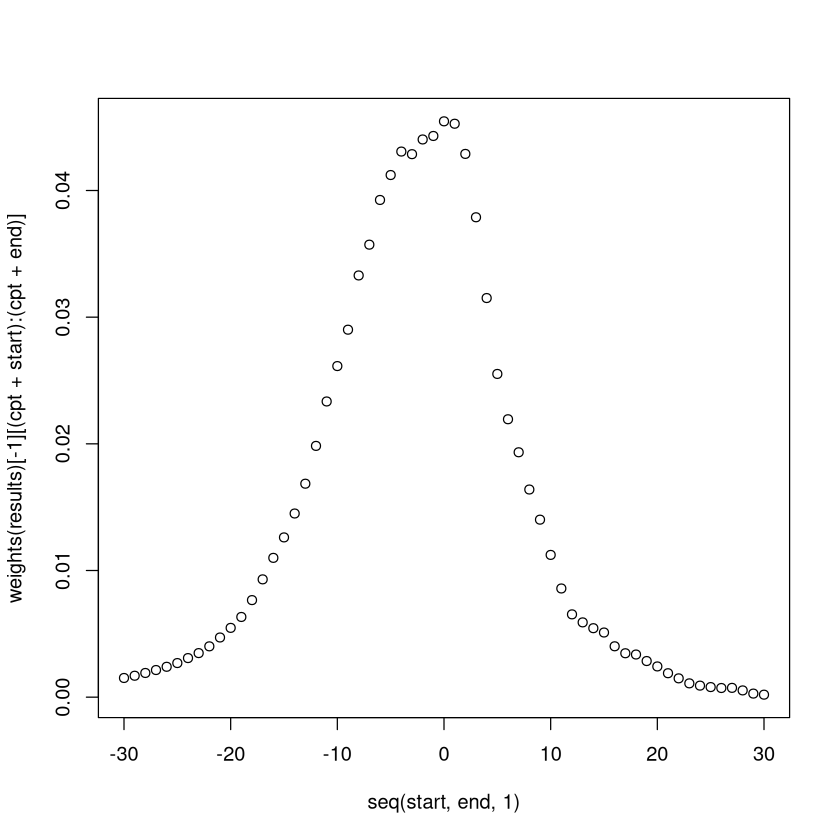

In [50]:
cpt = changepoint(results)$location
start <- -30
end <- 30
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

#### Offline analysis - unknown variance

In [51]:
results <- bagel_uv_approximate(Y,
					            feature_vector,
                                prior,
		                	    transform,
		                	    p0,
					            p,
					            nu,
                                iota,
					            max_particles,
					            threshold)

#### Check for a changepoint

In [52]:
changepoint(results)

$location
[1] 1032

$detected
[1] 1058

#### Visualise weight at tau = 0

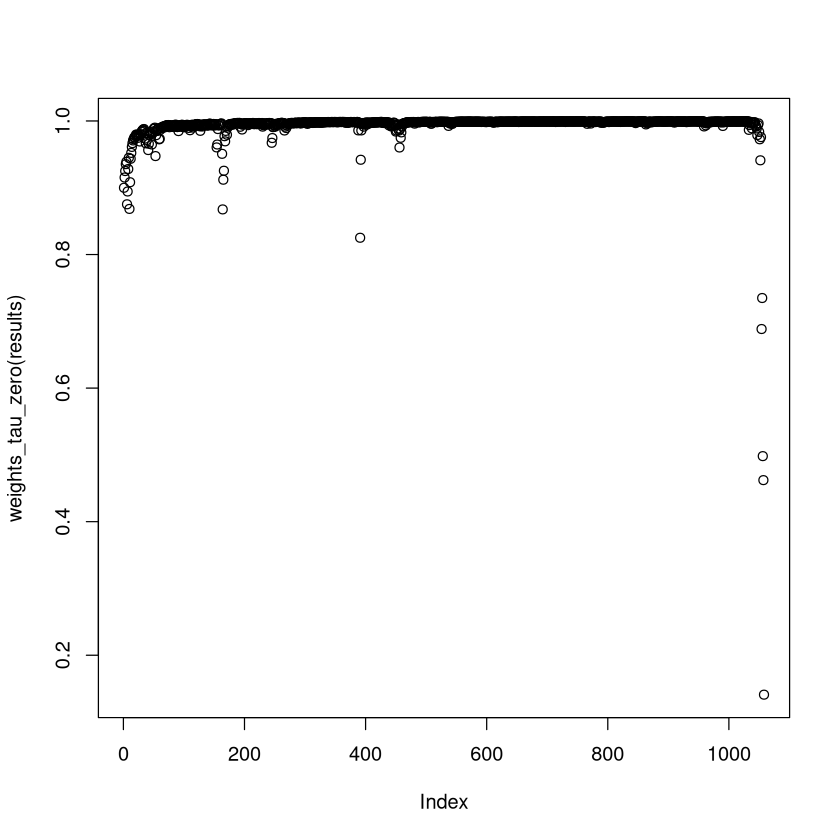

In [53]:
plot(weights_tau_zero(results))

#### Plot weights in region of changepoint

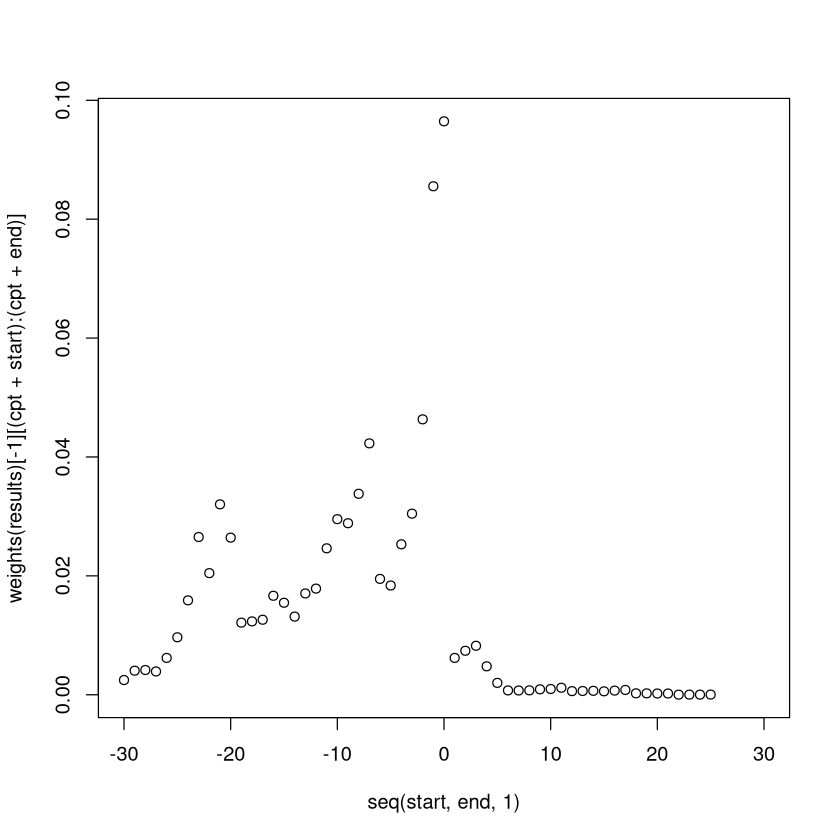

In [54]:
cpt = changepoint(results)$location
start <- -30
end <- 30
plot(seq(start,end,1),weights(results)[-1][(cpt+start):(cpt+end)])

### Other methods

### Get the taus

- Returns a vector of tau values for the active (unpruned) particles

In [55]:
taus(results)

[1]    0    1    2    3    4    5    8   11   18   26   34   40   47   52   58
 [16]   67   81   97  107  116  130  140  150  153  163  173  183  196  205  216
 [31]  225  230  238  244  254  265  271  292  303  324  349  363  370  376  382
 [46]  387  390  401  407  418  428  432  436  440  449  462  480  492  507  517
 [61]  529  536  552  577  590  600  608  618  634  652  666  677  686  697  705
 [76]  713  729  735  743  753  759  762  765  771  779  782  787  791  797  802
 [91]  808  814  820  826  833  837  842  845  847  850  854  856  858  860  862
[106]  864  866  868  871  874  878  882  886  889  893  895  899  901  904  907
[121]  909  913  916  918  920  921  923  926  928  929  931  933  935  937  939
[136]  941  943  944  945  946  947  948  949  950  951  952  953  954  955  956
[151]  957  958  959  960  961  963  964  965  966  967  968  969  970  971  972
[166]  973  974  975  976  977  978  979  980  981  982  983  984  985  986  987
[181]  988  989  990  991  992  993  994  995  996  997  998  999 1000 1001 1002
[196] 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014 1015 1016 1017
[211] 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028 1029 1030 1031 1032
[226] 1033 1034 1035 1036 1037 1038 1039 1040 1041 1042 1043 1044 1045 1046 1047
[241] 1048 1049 1050 1051 1052 1053 1054 1055 1056 1057

### Get the ratios

- Returns a list of vectors containing the ratios for each active (unpruned) particle

In [56]:
ratios <- ratios(results)
ratios[[44]]

[1] 0.08173681 0.11458243 0.13881826 0.19116194 0.21040994 0.26329062

### Get weights of active particles

- Returns a vector of weights for the currently active (unpruned) particles

In [57]:
active_weights(results)

[1] 1.409415e-01 7.082339e-06 4.776634e-06 3.542866e-06 3.439115e-06
  [6] 2.738948e-06 3.208645e-06 1.150008e-06 6.159579e-07 8.325317e-07
 [11] 1.049295e-06 1.320059e-06 9.313515e-07 6.621025e-07 2.240694e-07
 [16] 1.084725e-07 4.184886e-07 5.910930e-07 1.107781e-06 4.393276e-07
 [21] 8.445003e-07 2.104647e-07 1.168023e-06 4.462734e-07 6.810520e-07
 [26] 1.304916e-07 7.490111e-08 3.967458e-07 1.495851e-07 5.685315e-07
 [31] 6.299360e-07 4.286067e-07 2.365397e-07 7.678871e-07 8.588173e-08
 [36] 3.857237e-07 3.725756e-08 8.690228e-08 3.373032e-08 6.514776e-08
 [41] 6.942036e-08 1.619458e-07 2.242124e-07 1.553870e-07 2.830233e-07
 [46] 1.456068e-06 5.901936e-07 2.508271e-07 1.795978e-07 1.382283e-07
 [51] 7.244954e-07 3.391716e-07 8.434549e-07 3.695770e-07 1.464126e-07
 [56] 1.350064e-07 9.190962e-08 4.663310e-08 1.584082e-07 5.215385e-08
 [61] 1.299259e-07 1.363285e-07 4.372866e-08 8.483374e-08 1.611346e-07
 [66] 2.349546e-07 1.682561e-07 1.031419e-07 1.054273e-07 1.609220e-07
 [71] 9.655636e-08 8.859891e-08 1.022325e-07 9.450086e-08 6.649288e-08
 [76] 1.190104e-07 2.353361e-07 9.274997e-08 1.299732e-07 1.908626e-07
 [81] 3.553784e-07 7.280371e-07 6.201512e-07 1.287426e-06 6.991241e-07
 [86] 2.551743e-07 3.457459e-07 2.429287e-07 2.693049e-07 4.849162e-07
 [91] 3.130106e-07 5.604789e-07 4.806768e-07 4.381235e-07 7.339902e-07
 [96] 7.612488e-07 9.929995e-07 1.011854e-06 2.830719e-07 7.605370e-07
[101] 1.101107e-06 1.295939e-06 2.690563e-06 2.706383e-06 6.104163e-06
[106] 1.117576e-06 8.103734e-07 8.140118e-07 2.330757e-06 3.498522e-07
[111] 4.338328e-07 2.949310e-07 6.307181e-07 1.129709e-06 1.848128e-06
[116] 1.074456e-06 2.157145e-06 2.135825e-06 9.392734e-06 1.186877e-05
[121] 6.356489e-06 3.180338e-06 7.539520e-06 6.560612e-06 1.629392e-05
[126] 8.210403e-06 1.195286e-05 1.362156e-05 1.183013e-05 6.394458e-06
[131] 5.410333e-06 3.088941e-06 4.567793e-06 8.458701e-06 1.254651e-05
[136] 2.137263e-05 3.668107e-05 3.347290e-05 4.555745e-05 7.356778e-05
[141] 1.316295e-04 1.708916e-04 2.253979e-04 1.292873e-04 2.154050e-04
[146] 1.911113e-04 2.164670e-04 3.717005e-04 4.911914e-04 1.185866e-03
[151] 3.268591e-03 4.209880e-03 3.724442e-04 2.672669e-04 1.750206e-04
[156] 9.182327e-05 7.373534e-05 1.020106e-04 1.365090e-04 2.415316e-04
[161] 3.575171e-04 1.786647e-04 1.817771e-04 3.067092e-04 4.089044e-04
[166] 3.841177e-04 2.202732e-04 1.721238e-04 2.360593e-04 2.903459e-04
[171] 4.767736e-04 7.931237e-04 1.265926e-03 1.230485e-03 1.703442e-03
[176] 2.712237e-03 5.154774e-03 7.704824e-03 2.339412e-03 2.109319e-03
[181] 4.063535e-03 4.921668e-03 3.234281e-04 3.370081e-04 4.285141e-04
[186] 5.980235e-04 9.123239e-04 1.358690e-03 1.466518e-03 1.687928e-03
[191] 1.859316e-03 2.481329e-03 3.648968e-03 5.048797e-03 2.474040e-03
[196] 4.049563e-03 4.162284e-03 3.917282e-03 6.197376e-03 9.668356e-03
[201] 1.588028e-02 2.653423e-02 2.045833e-02 3.202978e-02 2.643104e-02
[206] 1.213102e-02 1.234026e-02 1.261954e-02 1.665190e-02 1.547589e-02
[211] 1.314634e-02 1.704058e-02 1.785733e-02 2.463323e-02 2.953992e-02
[216] 2.885357e-02 3.380452e-02 4.228861e-02 1.948786e-02 1.837487e-02
[221] 2.530784e-02 3.046111e-02 4.632785e-02 8.554039e-02 9.645964e-02
[226] 6.197897e-03 7.398023e-03 8.241048e-03 4.782699e-03 2.000078e-03
[231] 7.289390e-04 7.144507e-04 7.403747e-04 9.124257e-04 9.687370e-04
[236] 1.177545e-03 6.098692e-04 6.313269e-04 6.614863e-04 5.768222e-04
[241] 6.962407e-04 8.055543e-04 2.414911e-04 2.350449e-04 2.119482e-04
[246] 2.112888e-04 1.465966e-05 2.273822e-05 2.094111e-05 3.223740e-05